In [1]:
from tqdm import tqdm
import json
import torch
import os
from lego.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_VIDEO_TOKEN, DEFAULT_SOUND_TOKEN
from lego.conversation import SeparatorStyle
from lego import conversation as conversation_lib
from lego.mm_utils import tokenizer_image_token, KeywordsStoppingCriteria, load_image_square, postprocess_output
from lego.model.builder import CONFIG, load_pretrained_model
from video_llama.processors.video_processor import load_video
from video_llama.models.ImageBind.data import load_and_transform_audio_data
from lego.constants import DEFAULT_IMAGE_PATCH_TOKEN, DEFAULT_IMAGE_START_TOKEN, DEFAULT_IMAGE_END_TOKEN, DEFAULT_VIDEO_PATCH_TOKEN, \
                           DEFAULT_VIDEO_START_TOKEN, DEFAULT_VIDEO_END_TOKEN, DEFAULT_SOUND_PATCH_TOKEN, DEFAULT_SOUND_START_TOKEN, DEFAULT_SOUND_END_TOKEN

def replace_bounding_box_prompts(description,idx=1):
    prompts = [
        f"Identify and return the bounding box coordinates for the person described in: \"{description}\"",
        f"Generate bounding box coordinates for the person described: \"{description}\"",
        f"Output the bounding box coordinates for the individual characterized as follows: \"{description}\"",
        f"Locate and specify the bounding box coordinates for the person in this description: \"{description}\"",
        f"Calculate the bounding box coordinates for the person described here: \"{description}\"",
        f"Determine and output the bounding box coordinates for the following description of a person: \"{description}\"",
        f"Find the bounding box coordinates for the person with these details: \"{description}\"",
        f"Retrieve and display bounding box coordinates for the person whose description is: \"{description}\"",
        f"Give the bounding box coordinates for the individual described in the following: \"{description}\"",
        f"Generate the coordinates for the bounding box of the person as described here: \"{description}\""
    ]
    return prompts[idx]


model_path="ckpt/GroundingGPT"
image_path="/home/v-jinjzhao/datasets/rec_human/images_v2/val_ready/"
json_path='/home/v-jinjzhao/datasets/rec_human/person_annts_val_ready.json'
temperature=0.2
max_new_tokens=512
debug=True



model, tokenizer, image_processor, video_transform, context_len = load_pretrained_model(model_path)
conv = conversation_lib.default_conversation.copy()
roles = conv.roles
image_path = None
image_tensor = None
video_tensor = None
sound_tensor = None


/home/v-jinjzhao/miniconda3/envs/groundinggpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/v-jinjzhao/miniconda3/envs/groundinggpt/lib/python3.10/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/home/v-jinjzhao/miniconda3/envs/groundinggpt/lib/python3.10/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/home/v-jinjzhao/miniconda3/envs/groundinggpt/lib/python3.10/site-packages/torchvision/transforms/_functional_video.py:6: UserWarning: The 'torchvis

  0%|          | 0/10 [00:00<?, ?it/s]

[[339.2, 15.6, 486.4, 329]]


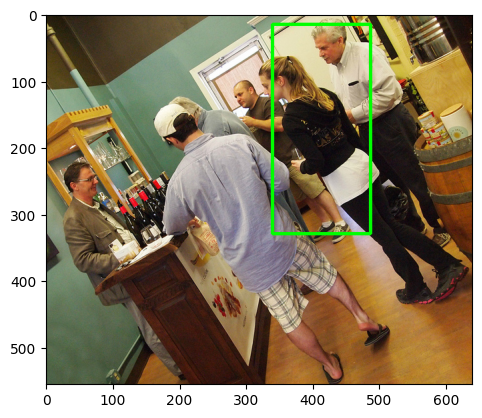

 10%|█         | 1/10 [00:01<00:11,  1.24s/it]

IOU: [tensor([[0.3083]])]
[[339.2, 15.6, 480.0, 329]]


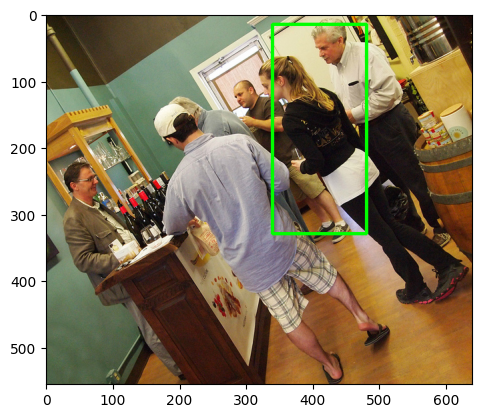

 20%|██        | 2/10 [00:02<00:10,  1.26s/it]

IOU: [tensor([[0.2962]])]
[[160.0, 79.6, 448.0, 508]]


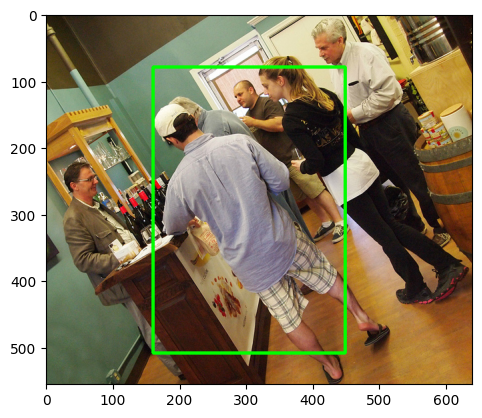

 30%|███       | 3/10 [00:03<00:08,  1.24s/it]

IOU: [tensor([[0.6585]])]
[[160.0, 79.6, 460.8, 508]]


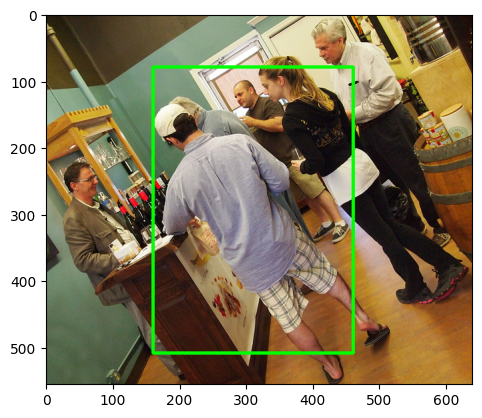

 40%|████      | 4/10 [00:04<00:07,  1.25s/it]

IOU: [tensor([[0.6834]])]
[[243.2, 14.6, 595.2, 418]]


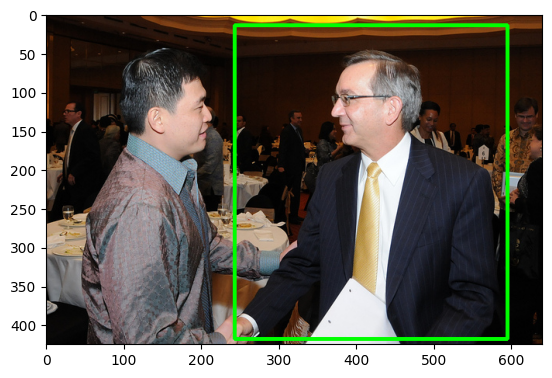

 50%|█████     | 5/10 [00:06<00:06,  1.23s/it]

IOU: [tensor([[0.8749]])]
[[236.8, 8.2, 595.2, 418]]


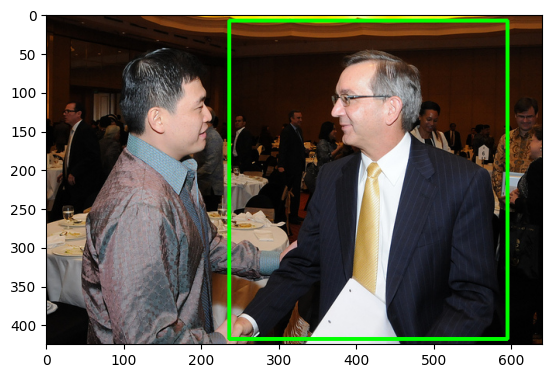

 60%|██████    | 6/10 [00:07<00:04,  1.24s/it]

IOU: [tensor([[0.8744]])]
[[44.8, 8.2, 300.8, 418]]


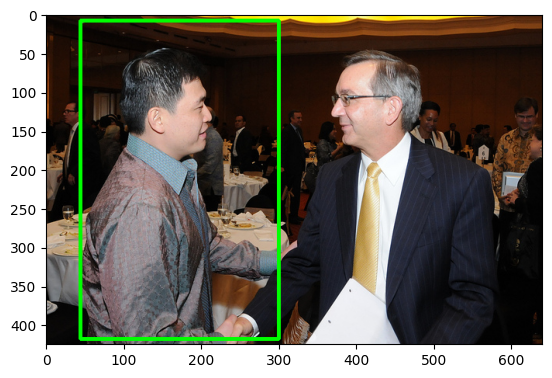

 70%|███████   | 7/10 [00:08<00:03,  1.23s/it]

IOU: [tensor([[0.8414]])]
[[38.4, 8.2, 300.8, 418]]


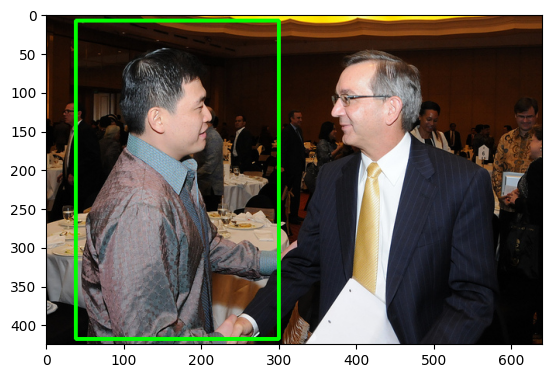

 80%|████████  | 8/10 [00:09<00:02,  1.24s/it]

IOU: [tensor([[0.8295]])]
[[93.0, 110.0, 358.0, 440]]


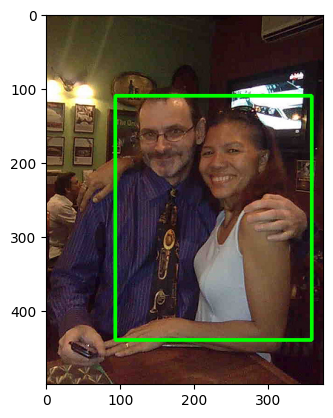

 90%|█████████ | 9/10 [00:11<00:01,  1.21s/it]

IOU: [tensor([[0.7612]])]
[[83.0, 120.0, 358.0, 440]]


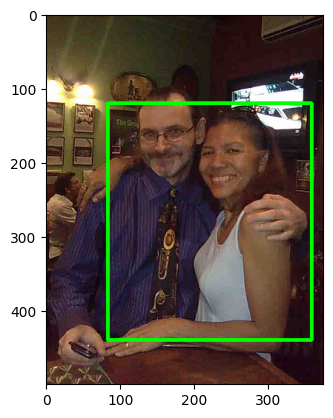

100%|██████████| 10/10 [00:12<00:00,  1.22s/it]

IOU: [tensor([[0.8139]])]


In [18]:
from lego.mm_utils import tokenizer_image_token, KeywordsStoppingCriteria, load_image_square, postprocess_box
import re
import numpy as np
import torch
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from overlaps import bbox_overlaps

def postprocess_output(outputs, image_file, absolute_coordinates=False):
    if image_file is None:
        return
    image = Image.open(image_file).convert('RGB')
    ori_width, ori_height = image.size
    max_ori = max(ori_width, ori_height)
    regex = re.compile(r'\[[0-9.]+, [0-9.]+, [0-9.]+, [0-9.]+\]')
    matches = re.findall(regex, outputs)
    new_bboxes = []
    for match in matches:
        try:
            x1, y1, x2, y2 = [float(part.strip()) for part in match.strip('[]').split(',')]
            square_bbox = round(x1 * max_ori,3), round(y1 * max_ori,3), round(x2 * max_ori,3), round(y2 * max_ori)
            ori_box = postprocess_box(square_bbox, ori_width, ori_height)
            if(absolute_coordinates):
                new_x1, new_y1, new_x2, new_y2 = [round(ori_box[0],3), round(ori_box[1],3), round(ori_box[2],3), round(ori_box[3],3)]
                new_x1 = np.clip(new_x1, 0, ori_width)
                new_y1 = np.clip(new_y1, 0, ori_height)
                new_x2 = np.clip(new_x2, 0, ori_width)
                new_y2 = np.clip(new_y2, 0, ori_height)
            else:
                new_x1, new_y1, new_x2, new_y2 = [round(ori_box[0]/ori_width,3), round(ori_box[1]/ori_height,3), round(ori_box[2]/ori_width,3), round(ori_box[3]/ori_height,3)]
                new_x1 = np.clip(new_x1, 0, 1)
                new_y1 = np.clip(new_y1, 0, 1)
                new_x2 = np.clip(new_x2, 0, 1)
                new_y2 = np.clip(new_y2, 0, 1)
            new_bbox = [new_x1, new_y1, new_x2, new_y2]
            new_bboxes.append(new_bbox)
        except:
            pass
    return new_bboxes

image_dir='/home/v-jinjzhao/datasets/rec_human_celeb_ready/images_v2/val_ready'
json_path='/home/v-jinjzhao/datasets/rec_human_celeb_ready/person_annts_val_ready.json'
with open(json_path) as f:
    annts=json.load(f)

for annt in tqdm(annts[:10]):
    file_name=annt['file_name']
    image_path=os.path.join(image_dir,file_name)
    try :
        image = load_image_square(image_path,image_processor)
        image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'].half().cuda()
        conv = conversation_lib.default_conversation.copy()
    except:
        print(f'{image_path} is not a correct image path.')
        continue
    

    inp=f"Provide coordinates for the bounding box around the person mentioned in: \"{annt['caption']}\""
    if model.config.mm_use_im_start_end:
        inp = DEFAULT_IMAGE_START_TOKEN + DEFAULT_IMAGE_PATCH_TOKEN * CONFIG.image_token_len + DEFAULT_IMAGE_END_TOKEN + '\n' + inp
    else:
        inp = DEFAULT_IMAGE_TOKEN + '\n' + inp
    conv.append_message(conv.roles[0], inp)
    image = None

    
    conv.append_message(conv.roles[1], None)
    prompt = conv.get_prompt()
    input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).cuda()
    stop_str = conv.sep if conv.sep_style != SeparatorStyle.TWO else conv.sep2
    keywords = [stop_str]
    stopping_criteria = KeywordsStoppingCriteria(keywords, tokenizer, input_ids)

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            videos=video_tensor,
            sounds=sound_tensor,
            do_sample=True,
            temperature=temperature,
            max_new_tokens=max_new_tokens, 
            use_cache=True,
            stopping_criteria=[stopping_criteria])
    
    outputs = tokenizer.decode(output_ids[0, input_ids.shape[1]:]).strip()
    if image_path is not None:
        outputs = postprocess_output(outputs, image_path, absolute_coordinates=True)

    print(outputs)
    gt_bbox=annt['bbox']
    x,y,w,h=gt_bbox
    gt_bbox=[x,y,x+w,y+h]
    img=cv2.imread(image_path) 
    iou=[]
    for bbox in outputs:
        x1,y1,x2,y2=[int(i) for i in bbox]
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),3)
        iou.append(bbox_overlaps(torch.tensor([x1,y1,x2,y2]).view(-1,4),torch.tensor(gt_bbox).view(-1,4)))

    plt.imshow(img[...,::-1])
    plt.show()
    print(f'IOU: {iou}')


    # if debug:
    #     print("\n", {"prompt": prompt, "outputs": outputs}, "\n")



In [21]:
import numpy as np

x=np.clip(0.5,0,1)
type(x.item())

float